# Brassica Models F1 Mean Across Folds and Combined ROC/AUC

### Imports and Directory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import scikit_posthocs as sp
from pathlib import Path

INPUT_DIR = Path("../brassica_outputs/model_outputs")
OUTPUT_DIR = INPUT_DIR / "combined_metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Load F1 Mean Summaries

In [2]:
f1_lf_mf1 = pd.read_csv(f"{INPUT_DIR}/lf_mf1_all_f1_mean.csv")
f1_lf_mf2  = pd.read_csv(f"{INPUT_DIR}/lf_mf2_all_f1_mean.csv")
f1_mf1_mf2  = pd.read_csv(f"{INPUT_DIR}/mf1_mf2_all_f1_mean.csv")

f1_combined = pd.concat([f1_lf_mf1, f1_lf_mf2, f1_mf1_mf2], ignore_index=True)
f1_combined["Model"] = ["LF-MF1", "LF-MF2", "MF1-MF2"]

display(f1_combined)

,model,f1_mean,f1_std,f1_pooled,Model
0,lf_mf1_all,0.702677,0.019240,0.702869,LF-MF1
1,lf_mf2_all,0.776783,0.012107,0.776840,LF-MF2
2,mf1_mf2_all,0.744731,0.030769,0.744797,MF1-MF2


### Load per-fold F1 Scores

In [3]:
lf_mf1_f1_concat = pd.read_csv(f"{INPUT_DIR}/lf_mf1_all_fold_f1.csv")
lf_mf2_f1_concat    = pd.read_csv(f"{INPUT_DIR}/lf_mf2_all_fold_f1.csv")
mf1_mf2_f1_concat    = pd.read_csv(f"{INPUT_DIR}/mf1_mf2_all_fold_f1.csv")

lf_mf1_f1_concat['group']    = 'lf_mf1'
lf_mf2_f1_concat['group']    = 'lf_mf2'
mf1_mf2_f1_concat['group']   = 'mf1_mf2'

f1_folds_concat = pd.concat(
    [lf_mf1_f1_concat, lf_mf2_f1_concat, mf1_mf2_f1_concat],
    ignore_index=True
)
display(f1_folds_concat)

,fold,f1,model,group
0,1,0.700405,lf_mf1_all,lf_mf1
1,2,0.723577,lf_mf1_all,lf_mf1
2,3,0.674948,lf_mf1_all,lf_mf1
3,4,0.708595,lf_mf1_all,lf_mf1
4,5,0.666667,lf_mf1_all,lf_mf1
5,6,0.693790,lf_mf1_all,lf_mf1
6,7,0.696356,lf_mf1_all,lf_mf1
7,8,0.721116,lf_mf1_all,lf_mf1
8,9,0.725838,lf_mf1_all,lf_mf1
9,10,0.715481,lf_mf1_all,lf_mf1


###  Kruskal-Wallis and Dunn's post-hoc

In [4]:
group_order = ['lf_mf1', 'lf_mf2', 'mf1_mf2']

# Omnibus test
groups_list = [f1_folds_concat[f1_folds_concat['group'] == g]['f1'].values
               for g in group_order]

stat, p_kruskal = kruskal(*groups_list)
print(f"Kruskal-Wallis H = {stat:.4f}, p = {p_kruskal:.4f}")

# Post-hoc Dunn's test — only interpret if Kruskal-Wallis is significant
dunn_matrix = sp.posthoc_dunn(
    f1_folds_concat,
    val_col='f1',
    group_col='group',
    p_adjust='fdr_bh'
)
display(dunn_matrix)

Kruskal-Wallis H = 17.8477, p = 0.0001


,lf_mf1,lf_mf2,mf1_mf2
lf_mf1,1.000000,0.000074,0.029174
lf_mf2,0.000074,1.000000,0.060162
mf1_mf2,0.029174,0.060162,1.000000


### F1 Bar Chart with Significance Brackets

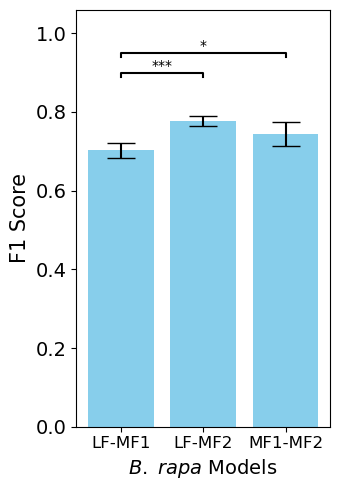

In [12]:
group_pos = {
    'lf_mf1':    0,
    'lf_mf2': 1,
    'mf1_mf2': 2,
}

def add_significance(ax, dunn_matrix, group_pos, y_start, y_buffer=0.04):
    """
    Draws significance brackets from a posthoc_dunn p-value matrix.
    Only iterates over the upper triangle to avoid duplicate pairs.
    """
    line_offset = 0
    groups = list(group_pos.keys())

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1, g2 = groups[i], groups[j]
            p_adj = dunn_matrix.loc[g1, g2]

            if p_adj < 0.05:
                x1 = group_pos[g1]
                x2 = group_pos[g2]
                y  = y_start + line_offset
                h  = 0.01

                ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')

                if p_adj < 0.001:
                    stars = '***'
                elif p_adj < 0.01:
                    stars = '**'
                else:
                    stars = '*'
                ax.text((x1 + x2)/2, y + h, stars, ha='center', va='bottom', fontsize=10)

                line_offset += y_buffer

x_pos  = np.arange(len(f1_combined))
fig, ax = plt.subplots(figsize=(3.5, 5))

ax.bar(x_pos, f1_combined["f1_mean"], yerr=f1_combined["f1_std"],
       capsize=10, color="skyblue")

ax.set_xticks(x_pos)
ax.set_xticklabels(["LF-MF1", "LF-MF2", "MF1-MF2"], fontsize=12)
ax.set_ylabel("F1 Score", fontsize=15)
ax.set_xlabel(r'$\it{B.\ rapa}$ Models', fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Set y limit to accommodate significance brackets
num_sig  = (dunn_matrix.values < 0.05).sum() // 2  # upper triangle only
base_y   = (f1_combined["f1_mean"] + f1_combined["f1_std"]).max() + 0.1
extra_y  = num_sig * 0.06
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_ylim(0, base_y + extra_y + 0.05)

add_significance(ax, dunn_matrix, group_pos, base_y, y_buffer=0.05)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/brapa_f1_bars_with_sig.png", bbox_inches='tight', dpi=600)
plt.show()

### Combined ROC curves

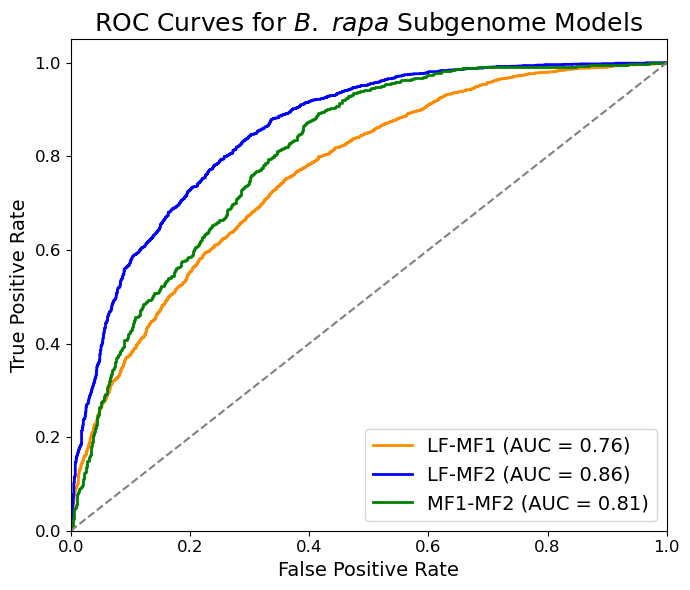

In [8]:
roc_files = [
    f"{INPUT_DIR}/lf_mf1_all_roc_data.csv",
    f"{INPUT_DIR}/lf_mf2_all_roc_data.csv",
    f"{INPUT_DIR}/mf1_mf2_all_roc_data.csv",
]

all_roc_data = pd.concat([pd.read_csv(f) for f in roc_files], ignore_index=True)

labels = {
    "lf_mf1_all":    "LF-MF1",
    "lf_mf2_all":    "LF-MF2",
    "mf1_mf2_all":   "MF1-MF2",
}
colors = ['darkorange', 'blue', 'green', 'red', 'teal']

fig, ax = plt.subplots(figsize=(7, 6))

for model_name, color in zip(all_roc_data["model"].unique(), colors):
    df      = all_roc_data[all_roc_data["model"] == model_name]
    auc_val = df["auc"].iloc[0]
    ax.plot(
        df["fpr"], df["tpr"],
        lw=2, color=color,
        label=f'{labels.get(model_name, model_name)} (AUC = {auc_val:.2f})'
    )

ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate", fontsize=14)
ax.set_title("ROC Curves for $\it{B. \ rapa}$ Subgenome Models", fontsize=18)
ax.tick_params(axis='both', labelsize=12)
ax.legend(loc="lower right", fontsize=14)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/brapa_combined_roc_curves.png", dpi=600)
plt.show()

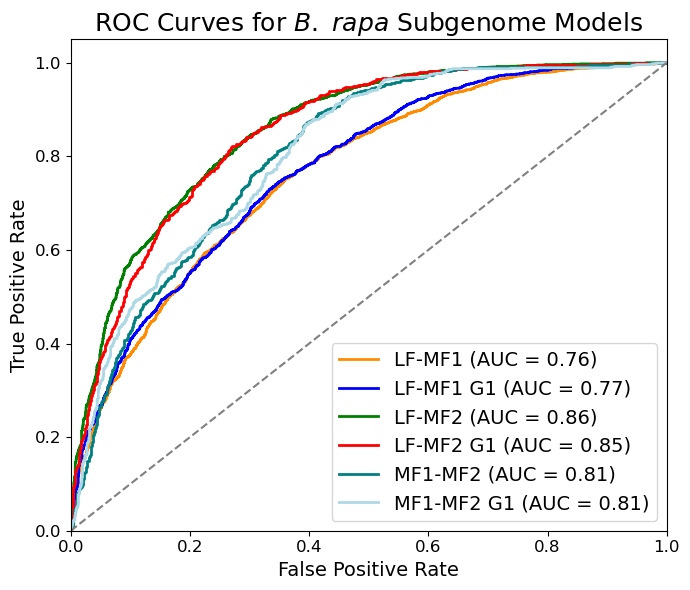

In [13]:
roc_files = [
    f"{INPUT_DIR}/lf_mf1_all_roc_data.csv",
    f"{INPUT_DIR}/lf_mf1_groupI_roc_data.csv",
    f"{INPUT_DIR}/lf_mf2_all_roc_data.csv",
    f"{INPUT_DIR}/lf_mf2_groupI_roc_data.csv",
    f"{INPUT_DIR}/mf1_mf2_all_roc_data.csv",
    f"{INPUT_DIR}/mf1_mf2_groupI_roc_data.csv",
]

all_roc_data = pd.concat([pd.read_csv(f) for f in roc_files], ignore_index=True)

labels = {
    "lf_mf1_all":      "LF-MF1",
    "lf_mf1_groupI":   "LF-MF1 G1",
    "lf_mf2_all":      "LF-MF2",
    "lf_mf2_groupI":   "LF-MF2 G1",
    "mf1_mf2_all":     "MF1-MF2",
    "mf1_mf2_groupI":  "MF1-MF2 G1",
}
colors = ['darkorange', 'blue', 'green', 'red', 'teal', 'lightblue']

fig, ax = plt.subplots(figsize=(7, 6))

for model_name, color in zip(all_roc_data["model"].unique(), colors):
    df      = all_roc_data[all_roc_data["model"] == model_name]
    auc_val = df["auc"].iloc[0]
    ax.plot(
        df["fpr"], df["tpr"],
        lw=2, color=color,
        label=f'{labels.get(model_name, model_name)} (AUC = {auc_val:.2f})'
    )

ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate", fontsize=14)
ax.set_title("ROC Curves for $\it{B. \ rapa}$ Subgenome Models", fontsize=18)
ax.tick_params(axis='both', labelsize=12)
ax.legend(loc="lower right", fontsize=14)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/brapa_combined_roc_curves_group1.png", dpi=600)
plt.show()

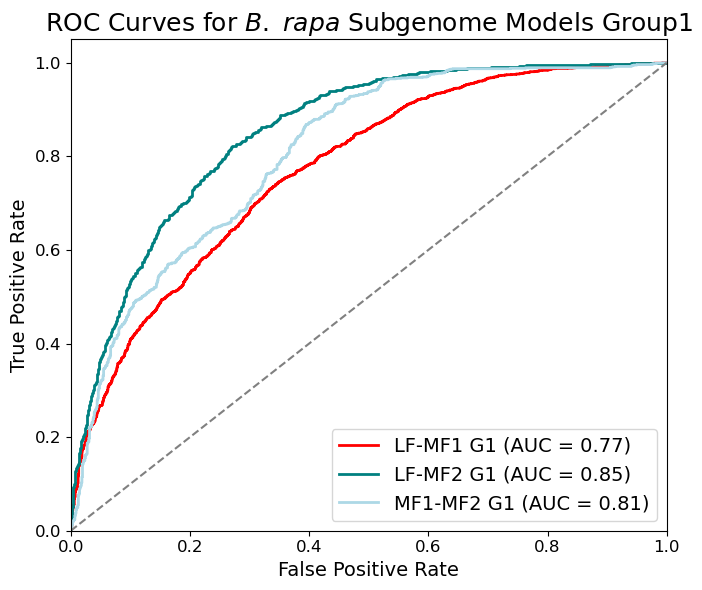

In [14]:
roc_files = [
    f"{INPUT_DIR}/lf_mf1_groupI_roc_data.csv",
    f"{INPUT_DIR}/lf_mf2_groupI_roc_data.csv",
    f"{INPUT_DIR}/mf1_mf2_groupI_roc_data.csv",
]

all_roc_data = pd.concat([pd.read_csv(f) for f in roc_files], ignore_index=True)

labels = {
    "lf_mf1_groupI":   "LF-MF1 G1",
    "lf_mf2_groupI":   "LF-MF2 G1",
    "mf1_mf2_groupI":  "MF1-MF2 G1",
}
colors = ['red', 'teal', 'lightblue']

fig, ax = plt.subplots(figsize=(7, 6))

for model_name, color in zip(all_roc_data["model"].unique(), colors):
    df      = all_roc_data[all_roc_data["model"] == model_name]
    auc_val = df["auc"].iloc[0]
    ax.plot(
        df["fpr"], df["tpr"],
        lw=2, color=color,
        label=f'{labels.get(model_name, model_name)} (AUC = {auc_val:.2f})'
    )

ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate", fontsize=14)
ax.set_title("ROC Curves for $\it{B. \ rapa}$ Subgenome Models Group1", fontsize=18)
ax.tick_params(axis='both', labelsize=12)
ax.legend(loc="lower right", fontsize=14)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/brapa_combined_roc_curves_group1_only.png", dpi=600)
plt.show()